# Question: If I simulate many participants with different true discount rates, can my estimation procedure reliably recover those rates?

This notebook tests whether the maximum-likelihood estimation procedure
can reliably recover delay-discounting parameters across participants
with different true values of k.

For each simulated participant:

1. Assign a known true k.
2. Generate probabilistic intertemporal choices.
3. Hide the true k from the estimator.
4. Estimate k using maximum likelihood.
5. Compare the estimated value with the known true value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def subjective_value(amount, delay, k):
    value = amount / (1 + k * delay)
    return value

def delayed_choice_probability(immediate_amount, delayed_amount, delay, k, beta):
    immediate_value = subjective_value(immediate_amount, 0, k)
    delayed_value = subjective_value(delayed_amount, delay, k)
    value_difference = delayed_value - immediate_value

    probability_delayed = 1 / (1 + np.exp(-beta * value_difference))

    return probability_delayed

def choose_reward_probabilistic(
    immediate_amount,
    delayed_amount,
    delay,
    k,
    beta
):
    p_delayed = delayed_choice_probability(
        immediate_amount,
        delayed_amount,
        delay,
        k,
        beta
    )

    random_draw = np.random.random()

    if random_draw < p_delayed:
        return "Delayed"
    else:
        return "Immediate"

def log_likelihood(k, beta, df):
    total = 0
    for _, row in df.iterrows():
        p_delayed = delayed_choice_probability(
            row["immediate"],
            row["delayed"],
            row["delay"],
            k,
            beta
        )
        p_delayed = np.clip(p_delayed, 1e-10, 1 - 1e-10)

        choice = row["choice"]
        if choice == "Delayed":
            total += np.log(p_delayed)
        else:
            total += np.log(1 - p_delayed)
    
    return total

In [6]:
true_k_values = [
    0.001,
    0.002,
    0.005,
    0.01,
    0.02,
    0.03,
    0.05,
    0.075,
    0.1
]

beta = 0.5 # Can we recover differences in k when everything else stays constant?

In [12]:
recovery_results = []

candidate_ks = np.linspace(0.001, 0.1, 300)

for true_k in true_k_values:
    observations = []

    for choice in choices:
        for trial in range(trials_per_choice):
            response = choose_reward_probabilistic(
                choice["immediate"],
                choice["delayed"],
                choice["delay"],
                true_k,
                beta
            )

            observations.append({
                "immediate": choice["immediate"],
                "delayed": choice["delayed"],
                "delay": choice["delay"],
                "choice": response
            })

    # Still inside the true_k loop
    participant_df = pd.DataFrame(observations)

    log_likelihoods = []

    for candidate_k in candidate_ks:
        ll = log_likelihood(
            candidate_k,
            beta,
            participant_df
        )

        log_likelihoods.append(ll)

    best_index = np.argmax(log_likelihoods)
    estimated_k = candidate_ks[best_index]

    recovery_results.append({
        "true_k": true_k,
        "estimated_k": estimated_k
    })

recovery_df = pd.DataFrame(recovery_results)
recovery_df

,true_k,estimated_k
0,0.001,0.001000
1,0.002,0.001993
2,0.005,0.004642
3,0.010,0.010271
4,0.020,0.024839
5,0.030,0.030137
6,0.050,0.054308
7,0.075,0.087087
8,0.100,0.074505


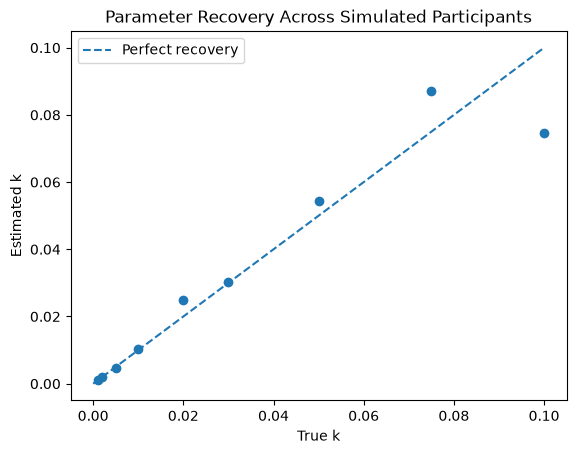

In [ ]:
plt.scatter(
    recovery_df["true_k"],
    recovery_df["estimated_k"]
)

plt.plot(
    [0, 0.1],
    [0, 0.1],
    linestyle="--",
    label="Perfect recovery"
)

plt.xlabel("True k")
plt.ylabel("Estimated k")
plt.title("Parameter Recovery Across Simulated Participants")
plt.legend()

plt.show()

Interpretation: Parameter recovery was highly accurate across low-to-moderate discount rates, with estimated values closely matching the simulated true values. Recovery became less precise at larger k values, suggesting that the current choice set may provide less information for distinguishing participants who heavily discount delayed rewards. When delayed rewards are consistently unattractive, different high discount rates can produce similar observable choice patterns.

In [17]:
recovery_df["error"] = (
    recovery_df["estimated_k"] - recovery_df["true_k"]
)

recovery_df["absolute_error"] = recovery_df["error"].abs()

recovery_df

,true_k,estimated_k,error,absolute_error
0,0.001,0.001000,0.000000,0.000000
1,0.002,0.001993,-0.000007,0.000007
2,0.005,0.004642,-0.000358,0.000358
3,0.010,0.010271,0.000271,0.000271
4,0.020,0.024839,0.004839,0.004839
5,0.030,0.030137,0.000137,0.000137
6,0.050,0.054308,0.004308,0.004308
7,0.075,0.087087,0.012087,0.012087
8,0.100,0.074505,-0.025495,0.025495


In [18]:
mean_absolute_error = recovery_df["absolute_error"].mean()

print("Mean absolute error:", mean_absolute_error)

Mean absolute error: 0.005277963582311408


Interpretation: The estimator recovered low-to-moderate discount rates closely, while estimation error increased for some larger values of k. This suggests that the current choice set contains less information for distinguishing participants with very steep discounting, because many high-k participants produce similarly strong preferences for immediate rewards. Overall recovery error provides a quantitative check on how reliably the model can infer latent discount rates from simulated choices.